In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load the cleaned data
df = pd.read_csv('../outputs/hle_at_birth_cleaned.csv')

# Create "Persons" data (average of Male and Female)
df_persons = df.groupby(['Area name', 'Area code', 'Period']).agg({
    'HLE': 'mean',
    'LE': 'mean',
    'HLE_Gap': 'mean'
}).reset_index()

# Pivot to see trends over time
df_trends = df_persons.pivot_table(
    index=['Area name', 'Area code'],
    columns='Period',
    values='HLE_Gap'
).reset_index()

# Count complete data
df_trends['periods_with_data'] = df_trends.iloc[:, 2:].notna().sum(axis=1)

# Keep only complete areas
df_complete = df_trends[df_trends['periods_with_data'] == 12].copy()
df_complete = df_complete.drop(columns=['periods_with_data'])

# Filter to England only
df_england = df_complete[df_complete['Area code'].str.startswith('E')].copy()

# Calculate change over time
earliest = '2011 to 2013'
latest = '2022 to 2024'

df_england['gap_2011_2013'] = df_england[earliest]
df_england['gap_2022_2024'] = df_england[latest]
df_england['total_change'] = df_england['gap_2022_2024'] - df_england['gap_2011_2013']
df_england['annual_change'] = df_england['total_change'] / 11

print(f"✓ Loaded and processed data")
print(f"✓ England local authorities: {len(df_england)}")
print(f"✓ Calculated changes")
print(f"\nAreas improving: {(df_england['total_change'] < 0).sum()}")
print(f"Areas worsening: {(df_england['total_change'] > 0).sum()}")

✓ Loaded and processed data
✓ England local authorities: 218
✓ Calculated changes

Areas improving: 20
Areas worsening: 198


In [1]:
# Load the IMD (Index of Multiple Deprivation) data
imd_file = '../data/imd_2025.xlsx'

# First, let's see what sheets are in this file
import pandas as pd
excel_imd = pd.ExcelFile(imd_file)
print("Sheets in IMD file:")
for i, sheet in enumerate(excel_imd.sheet_names, 1):
    print(f"{i}. {sheet}")

Sheets in IMD file:
1. Notes
2. IMD25


In [2]:
# Load the IMD data
df_imd = pd.read_excel(imd_file, sheet_name='IMD25')

print(f"✓ Loaded {len(df_imd)} rows")
print("\nFirst 10 rows:")
print(df_imd.head(10))
print("\nColumn names:")
print(df_imd.columns.tolist())

✓ Loaded 33755 rows

First 10 rows:
  LSOA code (2021)           LSOA name (2021)  \
0        E01000001        City of London 001A   
1        E01000002        City of London 001B   
2        E01000003        City of London 001C   
3        E01000005        City of London 001E   
4        E01000006  Barking and Dagenham 016A   
5        E01000007  Barking and Dagenham 015A   
6        E01000008  Barking and Dagenham 015B   
7        E01000009  Barking and Dagenham 016B   
8        E01000011  Barking and Dagenham 016C   
9        E01000012  Barking and Dagenham 015D   

  Local Authority District code (2024) Local Authority District name (2024)  \
0                            E09000001                       City of London   
1                            E09000001                       City of London   
2                            E09000001                       City of London   
3                            E09000001                       City of London   
4                            

In [3]:
# Group by Local Authority and calculate average deprivation
df_imd_la = df_imd.groupby([
    'Local Authority District code (2024)',
    'Local Authority District name (2024)'
]).agg({
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'mean',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA': 'mean'
}).reset_index()

# Rename columns for simplicity
df_imd_la.columns = ['LA_Code', 'LA_Name', 'IMD_Rank', 'IMD_Decile']

print(f"✓ Aggregated to {len(df_imd_la)} local authorities")
print("\nSample:")
print(df_imd_la.head(10))

print("\n" + "="*50)
print("Most deprived local authorities (lowest rank = most deprived):")
print(df_imd_la.nsmallest(10, 'IMD_Rank')[['LA_Name', 'IMD_Rank', 'IMD_Decile']])

✓ Aggregated to 296 local authorities

Sample:
     LA_Code                      LA_Name      IMD_Rank  IMD_Decile
0  E06000001                   Hartlepool  10524.561404    3.736842
1  E06000002                Middlesbrough   9514.622222    3.422222
2  E06000003         Redcar and Cleveland  12941.522727    4.375000
3  E06000004             Stockton-on-Tees  15832.540323    5.266129
4  E06000005                   Darlington  14656.106061    4.878788
5  E06000006                       Halton  12141.475000    4.137500
6  E06000007                   Warrington  20755.871212    6.621212
7  E06000008        Blackburn with Darwen   9321.252747    3.307692
8  E06000009                    Blackpool   7160.755319    2.755319
9  E06000010  Kingston upon Hull, City of   9520.750000    3.386905

Most deprived local authorities (lowest rank = most deprived):
                  LA_Name     IMD_Rank  IMD_Decile
8               Blackpool  7160.755319    2.755319
85               Hastings  8162.094340 

In [7]:
# Merge the deprivation data with your HLE trends
df_merged = df_england.merge(
    df_imd_la[['LA_Code', 'IMD_Rank', 'IMD_Decile']],
    left_on='Area code',
    right_on='LA_Code',
    how='left'
)

print(f"✓ Merged data: {len(df_merged)} areas")

# Check for any areas that didn't match
unmatched = df_merged[df_merged['IMD_Rank'].isna()]
print(f"\nAreas without deprivation data: {len(unmatched)}")
if len(unmatched) > 0:
    print(unmatched[['Area name', 'Area code']].head())

# Drop the duplicate LA_Code column
df_merged = df_merged.drop(columns=['LA_Code'])

print("\n✓ Merged dataset ready")
print("\nSample:")
print(df_merged[['Area name', 'total_change', 'IMD_Rank', 'IMD_Decile']].head(10))

✓ Merged data: 218 areas

Areas without deprivation data: 90
                          Area name  Area code
2                          Barnsley  E08000038
20                   Cambridgeshire  E10000003
21  Cambridgeshire and Peterborough  E47000008
33                       Derbyshire  E10000007
34                            Devon  E10000008

✓ Merged dataset ready

Sample:
                      Area name  total_change      IMD_Rank  IMD_Decile
0          Barking and Dagenham      0.078947   8722.460870    3.078261
1                        Barnet      7.271296  17019.754545    5.504545
2                      Barnsley      0.337852           NaN         NaN
3  Bath and North East Somerset      3.145118  23153.940678    7.313559
4                       Bedford      4.057802  17546.495726    5.675214
5                        Bexley      4.125765  21229.797297    6.777027
6                    Birmingham      0.672936   8954.295903    3.183612
7         Blackburn with Darwen      2.159536   

In [8]:
# See which areas didn't match
print("Areas in HLE data but NOT in IMD data:")
unmatched_list = df_merged[df_merged['IMD_Rank'].isna()]['Area name'].tolist()
print(f"\nTotal unmatched: {len(unmatched_list)}")
print("\nList of unmatched areas:")
for area in sorted(unmatched_list):
    print(f"  - {area}")

Areas in HLE data but NOT in IMD data:

Total unmatched: 90

List of unmatched areas:
  - Barnsley
  - Cambridgeshire
  - Cambridgeshire and Peterborough
  - Derbyshire
  - Devon
  - Devon and Torbay
  - East Midlands
  - East Midlands (Combined Authority)
  - East Sussex
  - East of England
  - England
  - Essex
  - Gloucestershire
  - Greater Lincolnshire
  - Greater Manchester
  - Hampshire
  - Hertfordshire
  - Hull and East Yorkshire
  - Kent
  - Lancashire
  - Lancashire (Combined Authority)
  - Leicestershire
  - Lincolnshire
  - Liverpool City Region
  - London
  - NHS Bath and North East Somerset, Swindon and Wiltshire Integrated Care Board
  - NHS Bedfordshire, Luton and Milton Keynes Integrated Care Board
  - NHS Birmingham and Solihull Integrated Care Board
  - NHS Black Country Integrated Care Board
  - NHS Bristol, North Somerset and South Gloucestershire Integrated Care Board
  - NHS Buckinghamshire, Oxfordshire and Berkshire West Integrated Care Board
  - NHS Cambridges

In [9]:
# The unmatched areas are mostly regional aggregates
# Let's keep only the areas that HAVE deprivation data (the real local authorities)

df_analysis = df_merged[df_merged['IMD_Rank'].notna()].copy()

print(f"✓ Filtered to areas with deprivation data")
print(f"✓ Final dataset: {len(df_analysis)} local authorities")
print(f"\nAreas improving: {(df_analysis['total_change'] < 0).sum()}")
print(f"Areas worsening: {(df_analysis['total_change'] > 0).sum()}")
print(f"Average change: {df_analysis['total_change'].mean():.2f} years")

print("\nSample of matched data:")
print(df_analysis[['Area name', 'total_change', 'IMD_Rank', 'IMD_Decile']].head(10))

✓ Filtered to areas with deprivation data
✓ Final dataset: 128 local authorities

Areas improving: 18
Areas worsening: 110
Average change: 2.61 years

Sample of matched data:
                              Area name  total_change      IMD_Rank  \
0                  Barking and Dagenham      0.078947   8722.460870   
1                                Barnet      7.271296  17019.754545   
3          Bath and North East Somerset      3.145118  23153.940678   
4                               Bedford      4.057802  17546.495726   
5                                Bexley      4.125765  21229.797297   
6                            Birmingham      0.672936   8954.295903   
7                 Blackburn with Darwen      2.159536   9321.252747   
8                             Blackpool      4.489367   7160.755319   
9                                Bolton      5.472725  12538.926554   
10  Bournemouth, Christchurch and Poole      3.678033  19141.162500   

    IMD_Decile  
0     3.078261  
1     5.5

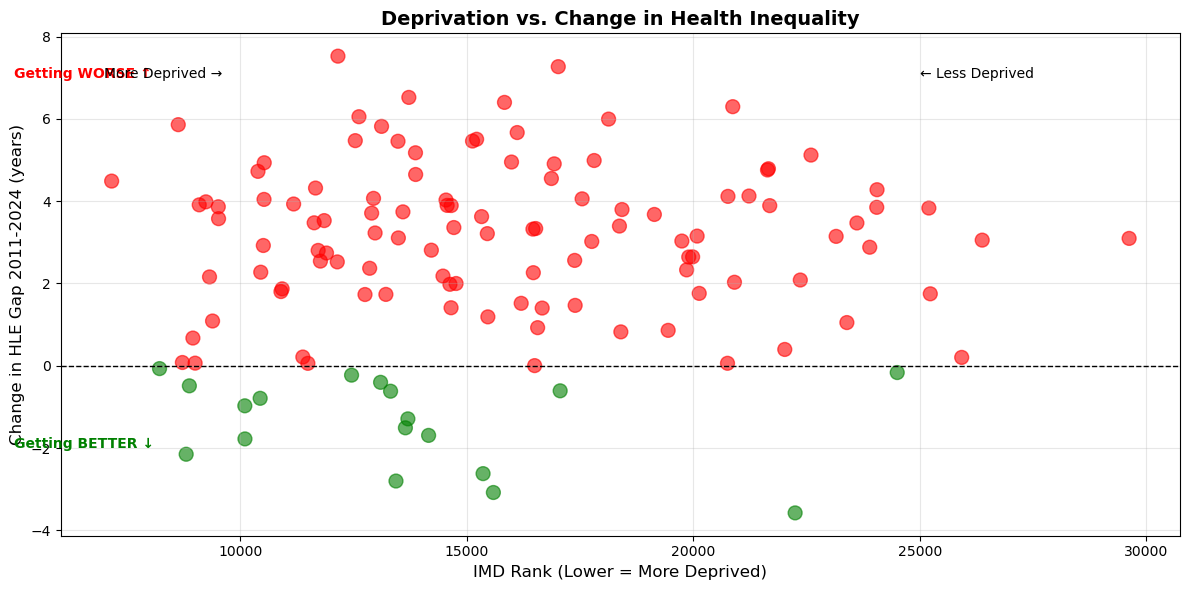

✓ Chart saved to outputs/deprivation_vs_change.png

Correlation between deprivation and worsening gap: 0.076
(Negative = more deprived areas getting worse)


In [10]:
# Create a scatter plot: Deprivation vs Change in HLE Gap
plt.figure(figsize=(12, 6))

# Plot with color coding
colors = ['green' if x < 0 else 'red' for x in df_analysis['total_change']]
plt.scatter(df_analysis['IMD_Rank'], df_analysis['total_change'], 
            c=colors, alpha=0.6, s=100)

# Add labels
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='No change')
plt.xlabel('IMD Rank (Lower = More Deprived)', fontsize=12)
plt.ylabel('Change in HLE Gap 2011-2024 (years)', fontsize=12)
plt.title('Deprivation vs. Change in Health Inequality', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add text
plt.text(5000, 7, 'Getting WORSE ↑', fontsize=10, color='red', fontweight='bold')
plt.text(5000, -2, 'Getting BETTER ↓', fontsize=10, color='green', fontweight='bold')
plt.text(25000, 7, '← Less Deprived', fontsize=10)
plt.text(7000, 7, 'More Deprived →', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/deprivation_vs_change.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to outputs/deprivation_vs_change.png")

# Calculate correlation
correlation = df_analysis['IMD_Rank'].corr(df_analysis['total_change'])
print(f"\nCorrelation between deprivation and worsening gap: {correlation:.3f}")
print("(Negative = more deprived areas getting worse)")

In [11]:
# Split areas into most deprived vs. least deprived
# Lower IMD Rank = more deprived

# Most deprived 25% (bottom quartile by rank)
most_deprived = df_analysis.nsmallest(32, 'IMD_Rank')
# Least deprived 25% (top quartile by rank)
least_deprived = df_analysis.nlargest(32, 'IMD_Rank')

print("MOST DEPRIVED AREAS (bottom 25%):")
print(f"  Average change: {most_deprived['total_change'].mean():.2f} years")
print(f"  % getting worse: {(most_deprived['total_change'] > 0).sum() / len(most_deprived) * 100:.1f}%")

print("\nLEAST DEPRIVED AREAS (top 25%):")
print(f"  Average change: {least_deprived['total_change'].mean():.2f} years")
print(f"  % getting worse: {(least_deprived['total_change'] > 0).sum() / len(least_deprived) * 100:.1f}%")

print("\n" + "="*50)
print("MOST DEPRIVED - Sample areas:")
print(most_deprived[['Area name', 'IMD_Rank', 'total_change']].head(10))

print("\nLEAST DEPRIVED - Sample areas:")
print(least_deprived[['Area name', 'IMD_Rank', 'total_change']].head(10))

MOST DEPRIVED AREAS (bottom 25%):
  Average change: 2.09 years
  % getting worse: 81.2%

LEAST DEPRIVED AREAS (top 25%):
  Average change: 2.65 years
  % getting worse: 93.8%

MOST DEPRIVED - Sample areas:
                Area name     IMD_Rank  total_change
8               Blackpool  7160.755319      4.489367
86             Manchester  8217.874576     -0.069444
161              Sandwell  8631.078947      5.861025
0    Barking and Dagenham  8722.460870      0.078947
134                Newham  8805.935135     -2.151703
78              Leicester  8876.075000     -0.488441
6              Birmingham  8954.295903      0.672936
53                Hackney  9003.684564      0.063158
146            Nottingham  9094.072626      3.911858
73               Knowsley  9241.840000      3.984944

LEAST DEPRIVED - Sample areas:
                  Area name      IMD_Rank  total_change
212               Wokingham  29621.708738      3.095723
210  Windsor and Maidenhead  26378.539326      3.053939
156    Rich

In [12]:
# Save the complete analysis dataset
df_analysis.to_csv('../outputs/final_analysis_with_deprivation.csv', index=False)

print("✓ Saved final analysis dataset")
print(f"\n📊 FINAL SUMMARY:")
print(f"   Total areas analyzed: {len(df_analysis)}")
print(f"   Areas improving: {(df_analysis['total_change'] < 0).sum()} ({(df_analysis['total_change'] < 0).sum()/len(df_analysis)*100:.1f}%)")
print(f"   Areas worsening: {(df_analysis['total_change'] > 0).sum()} ({(df_analysis['total_change'] > 0).sum()/len(df_analysis)*100:.1f}%)")
print(f"   National average: +{df_analysis['total_change'].mean():.2f} years worse")
print(f"\n   Most deprived average: +{most_deprived['total_change'].mean():.2f} years")
print(f"   Least deprived average: +{least_deprived['total_change'].mean():.2f} years")
print(f"   Difference: {least_deprived['total_change'].mean() - most_deprived['total_change'].mean():.2f} years")

✓ Saved final analysis dataset

📊 FINAL SUMMARY:
   Total areas analyzed: 128
   Areas improving: 18 (14.1%)
   Areas worsening: 110 (85.9%)
   National average: +2.61 years worse

   Most deprived average: +2.09 years
   Least deprived average: +2.65 years
   Difference: 0.55 years


In [13]:
# Calculate the projection to 2035 based on actual trends

# Time spans
baseline_year = 2022.5  # Midpoint of 2022-2024
target_year = 2035
years_ahead = target_year - baseline_year  # 12.5 years

# For each area, project forward using their actual rate of change
df_analysis['gap_2035_projected'] = (
    df_analysis['gap_2022_2024'] + 
    (df_analysis['annual_change'] * years_ahead)
)

print("✓ Calculated 2035 projections")
print("\nSample projections:")
print(df_analysis[['Area name', 'gap_2022_2024', 'annual_change', 'gap_2035_projected']].head(10))

print("\n" + "="*50)
print(f"Current average gap (2022-2024): {df_analysis['gap_2022_2024'].mean():.2f} years")
print(f"Projected average gap (2035): {df_analysis['gap_2035_projected'].mean():.2f} years")
print(f"Change: +{df_analysis['gap_2035_projected'].mean() - df_analysis['gap_2022_2024'].mean():.2f} years")

✓ Calculated 2035 projections

Sample projections:
                              Area name  gap_2022_2024  annual_change  \
0                  Barking and Dagenham      20.882749       0.007177   
1                                Barnet      21.897222       0.661027   
3          Bath and North East Somerset      17.959903       0.285920   
4                               Bedford      18.756962       0.368891   
5                                Bexley      20.544120       0.375070   
6                            Birmingham      21.050334       0.061176   
7                 Blackburn with Darwen      23.828169       0.196321   
8                             Blackpool      25.380212       0.408124   
9                                Bolton      24.162469       0.497520   
10  Bournemouth, Christchurch and Poole      20.543418       0.334367   

    gap_2035_projected  
0            20.972461  
1            30.160059  
3            21.533900  
4            23.368101  
5            25.2324

In [14]:
# Calculate the gap between most and least deprived areas

# Current gap (2022-2024) between rich and poor
current_most_deprived_gap = df_analysis.nsmallest(32, 'IMD_Rank')['gap_2022_2024'].mean()
current_least_deprived_gap = df_analysis.nlargest(32, 'IMD_Rank')['gap_2022_2024'].mean()
current_inequality = current_most_deprived_gap - current_least_deprived_gap

# Projected 2035 gap between rich and poor
projected_most_deprived_gap = df_analysis.nsmallest(32, 'IMD_Rank')['gap_2035_projected'].mean()
projected_least_deprived_gap = df_analysis.nlargest(32, 'IMD_Rank')['gap_2035_projected'].mean()
projected_inequality = projected_most_deprived_gap - projected_least_deprived_gap

# Government target: HALVE the current inequality
target_inequality = current_inequality / 2

print("🎯 GOVERNMENT TARGET vs. REALITY:")
print("="*60)
print(f"\nCURRENT (2022-2024):")
print(f"  Most deprived areas: {current_most_deprived_gap:.2f} years gap")
print(f"  Least deprived areas: {current_least_deprived_gap:.2f} years gap")
print(f"  Inequality (difference): {current_inequality:.2f} years")

print(f"\n2035 GOVERNMENT TARGET:")
print(f"  Target inequality: {target_inequality:.2f} years (half of current)")

print(f"\n2035 ACTUAL PROJECTION (if trends continue):")
print(f"  Most deprived areas: {projected_most_deprived_gap:.2f} years gap")
print(f"  Least deprived areas: {projected_least_deprived_gap:.2f} years gap")
print(f"  Projected inequality: {projected_inequality:.2f} years")

print("\n" + "="*60)
print(f"❌ GAP FROM TARGET: {projected_inequality - target_inequality:.2f} years")
print(f"❌ Instead of halving, inequality will INCREASE by {projected_inequality - current_inequality:.2f} years")

🎯 GOVERNMENT TARGET vs. REALITY:

CURRENT (2022-2024):
  Most deprived areas: 22.86 years gap
  Least deprived areas: 18.44 years gap
  Inequality (difference): 4.42 years

2035 GOVERNMENT TARGET:
  Target inequality: 2.21 years (half of current)

2035 ACTUAL PROJECTION (if trends continue):
  Most deprived areas: 25.24 years gap
  Least deprived areas: 21.45 years gap
  Projected inequality: 3.79 years

❌ GAP FROM TARGET: 1.58 years
❌ Instead of halving, inequality will INCREASE by -0.63 years


In [15]:
# Create traffic light categories based on change
# Green: improving (negative change)
# Amber: worsening slowly (0 to +3 years)
# Red: worsening badly (+3 years or more)

def classify_status(change):
    if change < 0:
        return 'On Track (Improving)'
    elif change < 3:
        return 'Borderline (Slow Decline)'
    else:
        return 'Off Track (Rapid Decline)'

df_analysis['status_2035'] = df_analysis['total_change'].apply(classify_status)

print("📊 2035 STATUS BREAKDOWN:")
print("="*50)
status_counts = df_analysis['status_2035'].value_counts()
print(status_counts)

print("\n🟢 ON TRACK (Improving):")
on_track = df_analysis[df_analysis['status_2035'] == 'On Track (Improving)']
print(f"   {len(on_track)} areas ({len(on_track)/len(df_analysis)*100:.1f}%)")
print("   Sample:", on_track['Area name'].head(5).tolist())

print("\n🟡 BORDERLINE (Slow Decline):")
borderline = df_analysis[df_analysis['status_2035'] == 'Borderline (Slow Decline)']
print(f"   {len(borderline)} areas ({len(borderline)/len(df_analysis)*100:.1f}%)")

print("\n🔴 OFF TRACK (Rapid Decline):")
off_track = df_analysis[df_analysis['status_2035'] == 'Off Track (Rapid Decline)']
print(f"   {len(off_track)} areas ({len(off_track)/len(df_analysis)*100:.1f}%)")
print("   Sample:", off_track.nlargest(5, 'total_change')['Area name'].tolist())

📊 2035 STATUS BREAKDOWN:
status_2035
Off Track (Rapid Decline)    65
Borderline (Slow Decline)    45
On Track (Improving)         18
Name: count, dtype: int64

🟢 ON TRACK (Improving):
   18 areas (14.1%)
   Sample: ['Brent', 'Croydon', 'Ealing', 'Gateshead', 'Hammersmith and Fulham']

🟡 BORDERLINE (Slow Decline):
   45 areas (35.2%)

🔴 OFF TRACK (Rapid Decline):
   65 areas (50.8%)
   Sample: ['Lewisham', 'Barnet', 'North East Lincolnshire', 'Stockton-on-Tees', 'East Riding of Yorkshire']


In [16]:
# Best performers (biggest improvement)
print("🏆 TOP 10 BEST PERFORMERS (Biggest Improvement):")
print("="*70)
best = df_analysis.nsmallest(10, 'total_change')[
    ['Area name', 'gap_2011_2013', 'gap_2022_2024', 'total_change', 'gap_2035_projected', 'IMD_Decile']
]
print(best.to_string(index=False))

print("\n\n💀 TOP 10 WORST PERFORMERS (Biggest Decline):")
print("="*70)
worst = df_analysis.nlargest(10, 'total_change')[
    ['Area name', 'gap_2011_2013', 'gap_2022_2024', 'total_change', 'gap_2035_projected', 'IMD_Decile']
]
print(worst.to_string(index=False))

print("\n\n📌 KEY INSIGHTS FOR YOUR POLICY BRIEF:")
print("="*70)
print(f"• Best performer: {best.iloc[0]['Area name']} (improved by {abs(best.iloc[0]['total_change']):.2f} years)")
print(f"• Worst performer: {worst.iloc[0]['Area name']} (worsened by {worst.iloc[0]['total_change']:.2f} years)")
print(f"• Range: {worst.iloc[0]['total_change'] - best.iloc[0]['total_change']:.2f} years between best and worst")

🏆 TOP 10 BEST PERFORMERS (Biggest Improvement):
             Area name  gap_2011_2013  gap_2022_2024  total_change  gap_2035_projected  IMD_Decile
                Sutton      18.139474      14.562169     -3.577304           10.497051    7.065041
               Croydon      18.349867      15.268223     -3.081644           11.766355    5.126638
        Waltham Forest      19.989119      17.186203     -2.802916           14.001072    4.493151
Hammersmith and Fulham      18.320833      15.697873     -2.622961           12.717235    5.086957
                Newham      21.015205      18.863502     -2.151703           16.418386    3.097297
         Tower Hamlets      23.263530      21.484878     -1.778652           19.463682    3.497041
   Newcastle upon Tyne      20.860731      19.167360     -1.693371           17.243075    4.727778
             Southwark      20.279550      18.770253     -1.509297           17.055143    4.578035
                Slough      20.567304      19.275974     -1.2

In [17]:
# Save the complete analysis with projections and status
df_analysis.to_csv('../outputs/final_analysis_with_projections.csv', index=False)

print("✓ Saved complete analysis")

# Create a summary statistics file for easy reference
summary_stats = {
    'Metric': [
        'Total areas analyzed',
        'Areas improving (green)',
        'Areas borderline (amber)', 
        'Areas declining (red)',
        'Current average HLE gap (2022-2024)',
        'Projected average HLE gap (2035)',
        'Average change',
        'Most deprived areas - current gap',
        'Least deprived areas - current gap',
        'Current inequality gap',
        'Target inequality gap (2035)',
        'Projected inequality gap (2035)'
    ],
    'Value': [
        len(df_analysis),
        len(on_track),
        len(borderline),
        len(off_track),
        f"{df_analysis['gap_2022_2024'].mean():.2f} years",
        f"{df_analysis['gap_2035_projected'].mean():.2f} years",
        f"+{df_analysis['total_change'].mean():.2f} years",
        f"{current_most_deprived_gap:.2f} years",
        f"{current_least_deprived_gap:.2f} years",
        f"{current_inequality:.2f} years",
        f"{target_inequality:.2f} years",
        f"{projected_inequality:.2f} years"
    ]
}

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('../outputs/summary_statistics.csv', index=False)

print("✓ Saved summary statistics")
print("\n📊 SUMMARY:")
print(df_summary.to_string(index=False))

✓ Saved complete analysis
✓ Saved summary statistics

📊 SUMMARY:
                             Metric       Value
               Total areas analyzed         128
            Areas improving (green)          18
           Areas borderline (amber)          45
              Areas declining (red)          65
Current average HLE gap (2022-2024) 20.92 years
   Projected average HLE gap (2035) 23.88 years
                     Average change +2.61 years
  Most deprived areas - current gap 22.86 years
 Least deprived areas - current gap 18.44 years
             Current inequality gap  4.42 years
       Target inequality gap (2035)  2.21 years
    Projected inequality gap (2035)  3.79 years


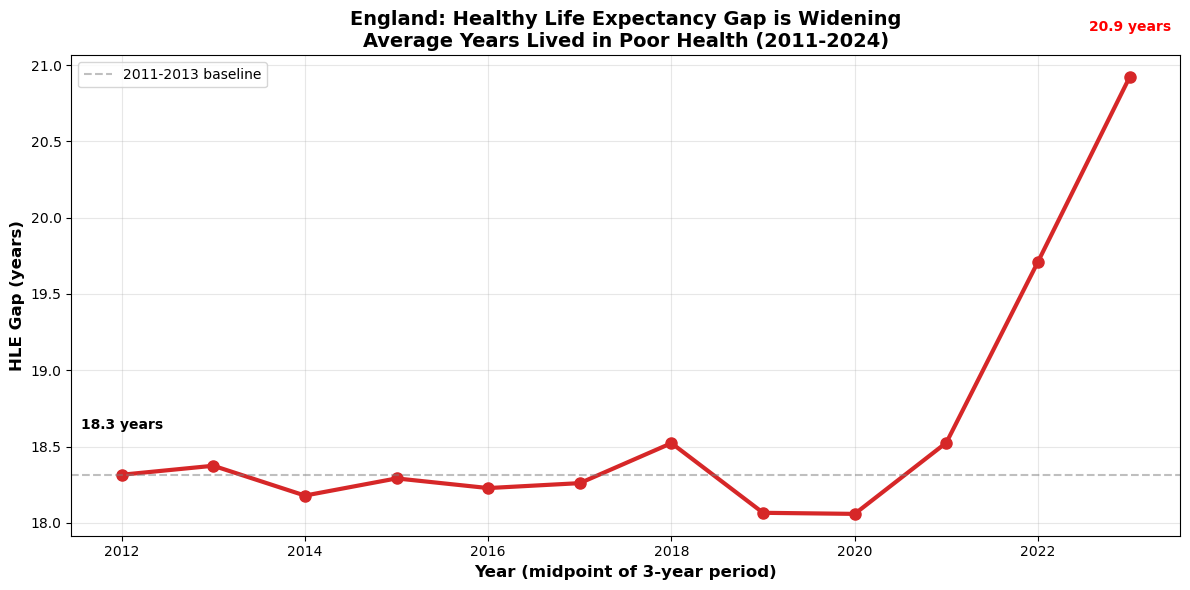

✓ Chart 1 saved: National trend over time
   2011-2013: 18.32 years
   2022-2024: 20.92 years
   Change: +2.61 years


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate national average for each time period
time_periods = ['2011 to 2013', '2012 to 2014', '2013 to 2015', '2014 to 2016', 
                '2015 to 2017', '2016 to 2018', '2017 to 2019', '2018 to 2020',
                '2019 to 2021', '2020 to 2022', '2021 to 2023', '2022 to 2024']

# Calculate average gap for each period
period_cols = [col for col in df_analysis.columns if 'to' in str(col) and col in time_periods]
national_avg = [df_analysis[period].mean() for period in period_cols]

# Create years for x-axis (use midpoint of each period)
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(years, national_avg, marker='o', linewidth=3, markersize=8, color='#d62728')
plt.axhline(y=national_avg[0], color='gray', linestyle='--', alpha=0.5, label='2011-2013 baseline')

plt.xlabel('Year (midpoint of 3-year period)', fontsize=12, fontweight='bold')
plt.ylabel('HLE Gap (years)', fontsize=12, fontweight='bold')
plt.title('England: Healthy Life Expectancy Gap is Widening\nAverage Years Lived in Poor Health (2011-2024)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Add annotations
plt.text(2012, national_avg[0] + 0.3, f'{national_avg[0]:.1f} years', 
         fontsize=10, ha='center', fontweight='bold')
plt.text(2023, national_avg[-1] + 0.3, f'{national_avg[-1]:.1f} years', 
         fontsize=10, ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('../outputs/chart1_national_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 1 saved: National trend over time")
print(f"   2011-2013: {national_avg[0]:.2f} years")
print(f"   2022-2024: {national_avg[-1]:.2f} years")
print(f"   Change: +{national_avg[-1] - national_avg[0]:.2f} years")

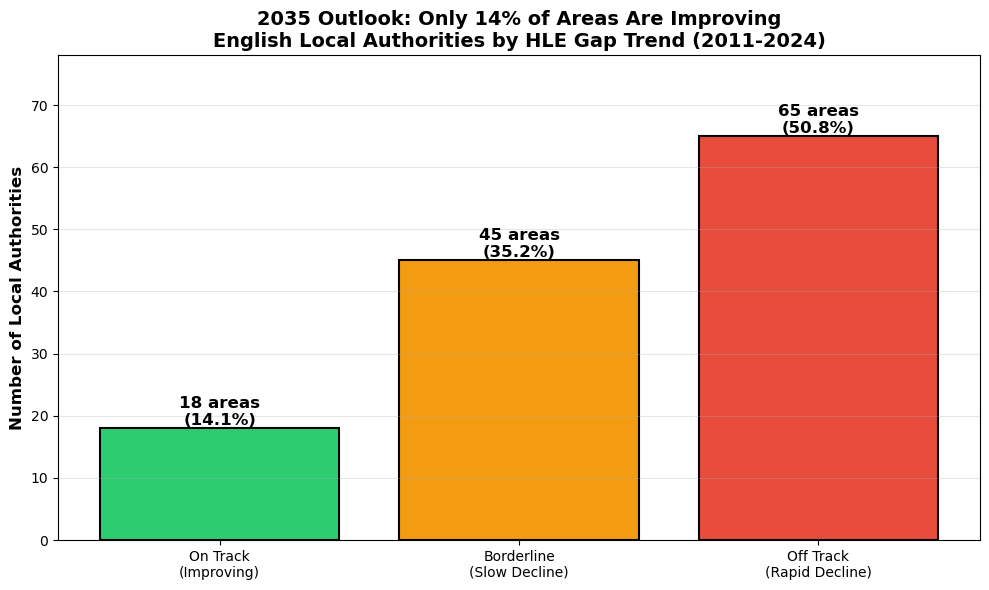

✓ Chart 2 saved: Traffic light status breakdown


In [19]:
# Create traffic light bar chart
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['On Track\n(Improving)', 'Borderline\n(Slow Decline)', 'Off Track\n(Rapid Decline)']
counts = [len(on_track), len(borderline), len(off_track)]
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, amber, red
percentages = [c/len(df_analysis)*100 for c in counts]

bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count} areas\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Local Authorities', fontsize=12, fontweight='bold')
ax.set_title('2035 Outlook: Only 14% of Areas Are Improving\nEnglish Local Authorities by HLE Gap Trend (2011-2024)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/chart2_traffic_light.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 2 saved: Traffic light status breakdown")

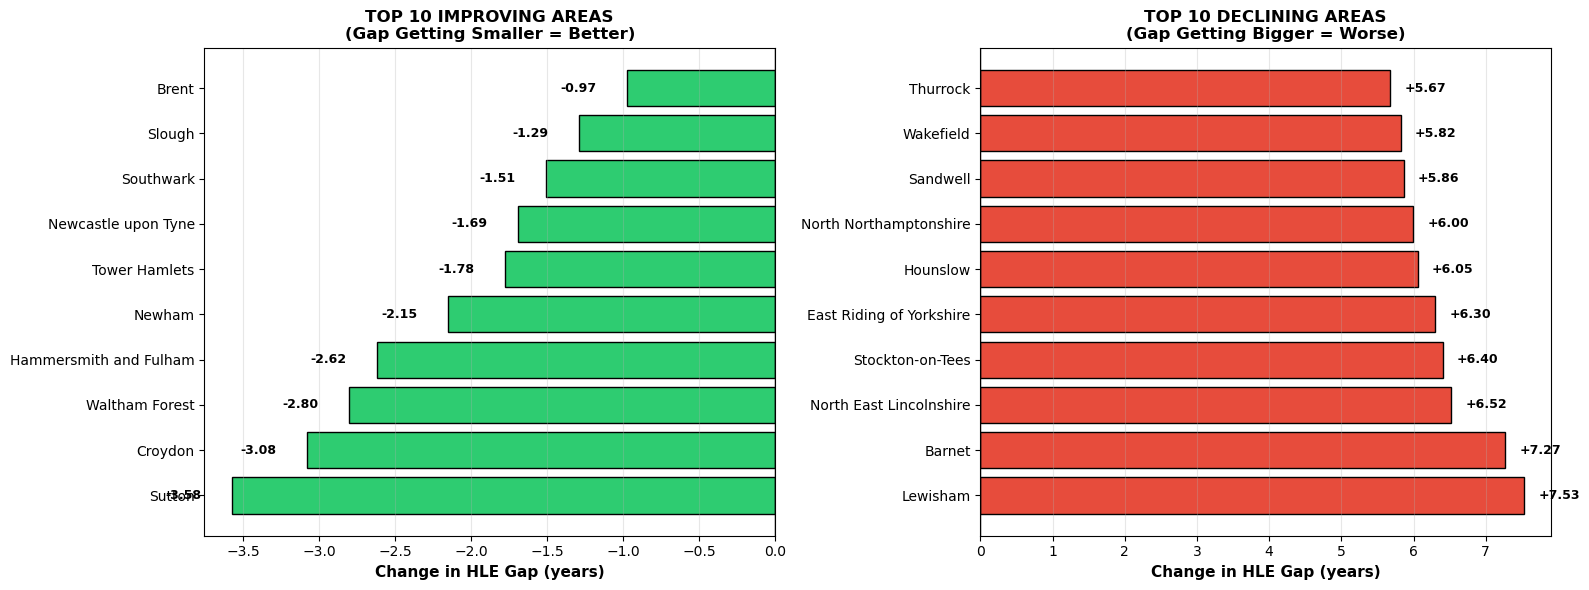

✓ Chart 3 saved: Best vs worst performers


In [20]:
# Get top 10 best and worst
top_10_best = df_analysis.nsmallest(10, 'total_change')[['Area name', 'total_change']].sort_values('total_change')
top_10_worst = df_analysis.nlargest(10, 'total_change')[['Area name', 'total_change']].sort_values('total_change', ascending=False)

# Create side-by-side chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Best performers (left)
ax1.barh(top_10_best['Area name'], top_10_best['total_change'], color='#2ecc71', edgecolor='black')
ax1.set_xlabel('Change in HLE Gap (years)', fontsize=11, fontweight='bold')
ax1.set_title('TOP 10 IMPROVING AREAS\n(Gap Getting Smaller = Better)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=1)
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(top_10_best['total_change']):
    ax1.text(v - 0.2, i, f'{v:.2f}', ha='right', va='center', fontweight='bold', fontsize=9)

# Worst performers (right)
ax2.barh(top_10_worst['Area name'], top_10_worst['total_change'], color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Change in HLE Gap (years)', fontsize=11, fontweight='bold')
ax2.set_title('TOP 10 DECLINING AREAS\n(Gap Getting Bigger = Worse)', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linewidth=1)
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(top_10_worst['total_change']):
    ax2.text(v + 0.2, i, f'+{v:.2f}', ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/chart3_best_worst.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 3 saved: Best vs worst performers")

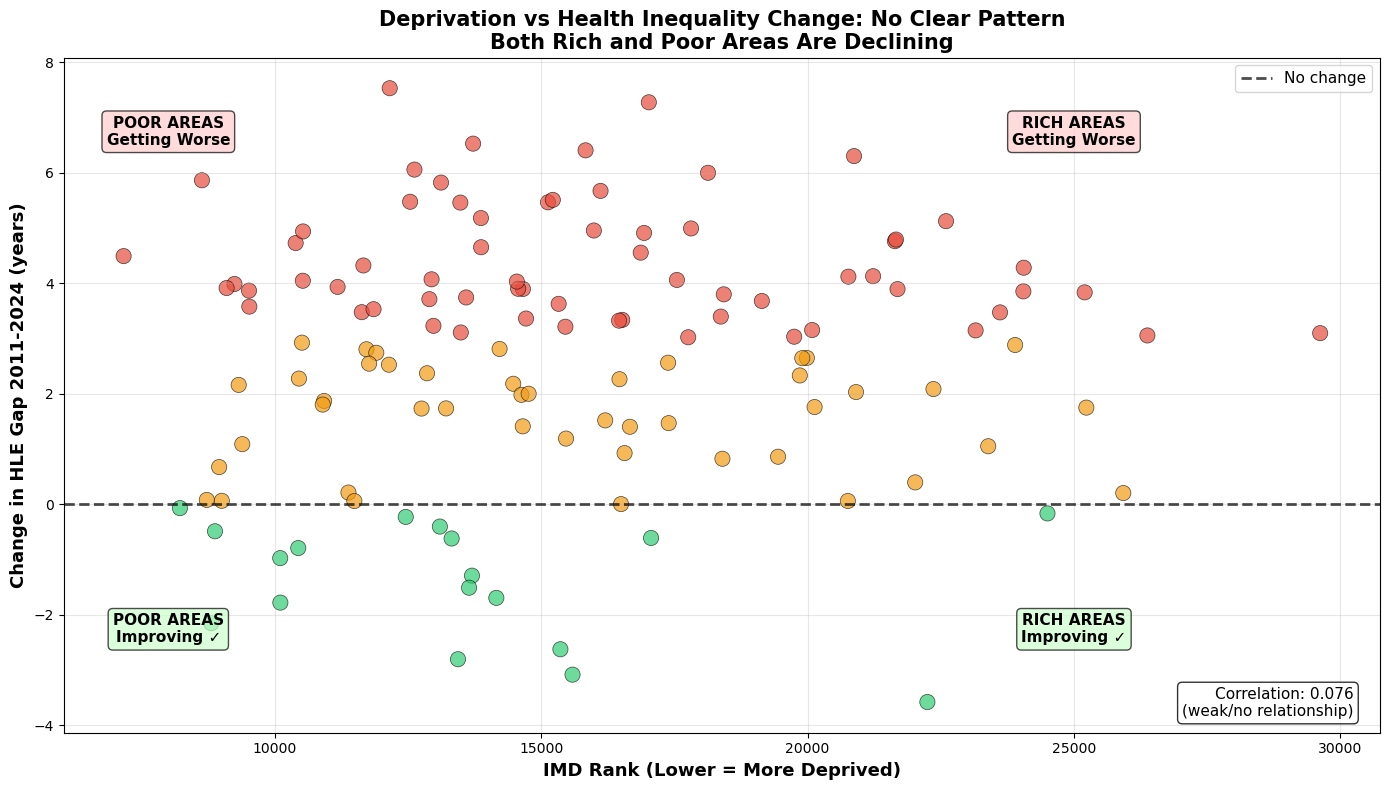

✓ Chart 4 saved: Deprivation vs change scatter plot
   Correlation: 0.076 (deprivation NOT driving the trend)


In [21]:
# Create enhanced scatter plot with annotations
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot with color coding
colors = ['#2ecc71' if x < 0 else '#f39c12' if x < 3 else '#e74c3c' 
          for x in df_analysis['total_change']]

scatter = ax.scatter(df_analysis['IMD_Rank'], df_analysis['total_change'], 
                     c=colors, s=120, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add horizontal line at zero
ax.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='No change')

# Labels and title
ax.set_xlabel('IMD Rank (Lower = More Deprived)', fontsize=13, fontweight='bold')
ax.set_ylabel('Change in HLE Gap 2011-2024 (years)', fontsize=13, fontweight='bold')
ax.set_title('Deprivation vs Health Inequality Change: No Clear Pattern\nBoth Rich and Poor Areas Are Declining', 
             fontsize=15, fontweight='bold')

# Add quadrant labels
ax.text(8000, 6.5, 'POOR AREAS\nGetting Worse', fontsize=11, fontweight='bold', 
        ha='center', bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.7))
ax.text(25000, 6.5, 'RICH AREAS\nGetting Worse', fontsize=11, fontweight='bold', 
        ha='center', bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.7))
ax.text(8000, -2.5, 'POOR AREAS\nImproving ✓', fontsize=11, fontweight='bold', 
        ha='center', bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.7))
ax.text(25000, -2.5, 'RICH AREAS\nImproving ✓', fontsize=11, fontweight='bold', 
        ha='center', bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.7))

# Add correlation text
correlation = df_analysis['IMD_Rank'].corr(df_analysis['total_change'])
ax.text(0.98, 0.02, f'Correlation: {correlation:.3f}\n(weak/no relationship)', 
        transform=ax.transAxes, fontsize=11, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/chart4_deprivation_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 4 saved: Deprivation vs change scatter plot")
print(f"   Correlation: {correlation:.3f} (deprivation NOT driving the trend)")

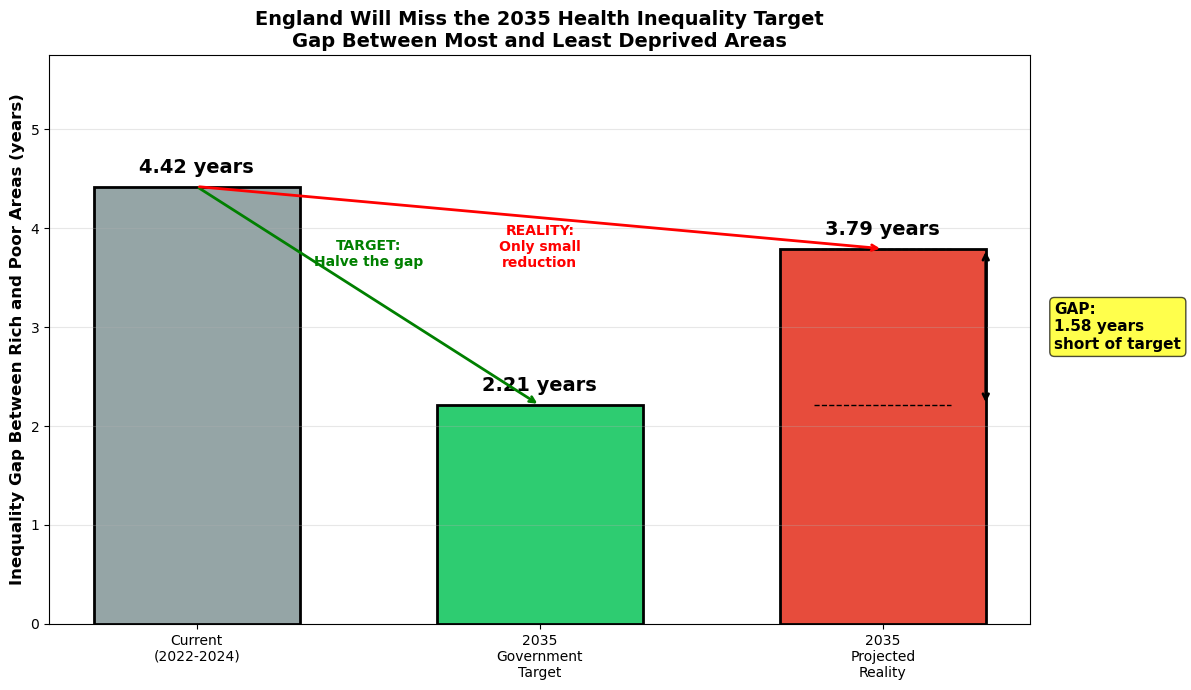

✓ Chart 5 saved: 2035 target vs projected reality

📊 THE VERDICT:
   Target: 2.21 years
   Reality: 3.79 years
   Missing by: 1.58 years


In [22]:
# Create comparison chart: Target vs Reality
fig, ax = plt.subplots(figsize=(12, 7))

categories = ['Current\n(2022-2024)', '2035\nGovernment\nTarget', '2035\nProjected\nReality']
values = [current_inequality, target_inequality, projected_inequality]
colors = ['#95a5a6', '#2ecc71', '#e74c3c']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=2, width=0.6)

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{val:.2f} years',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add arrows and annotations
ax.annotate('', xy=(1, target_inequality), xytext=(0, current_inequality),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.text(0.5, (current_inequality + target_inequality)/2 + 0.3, 
        'TARGET:\nHalve the gap', ha='center', fontsize=10, fontweight='bold', color='green')

ax.annotate('', xy=(2, projected_inequality), xytext=(0, current_inequality),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.text(1, (current_inequality + projected_inequality)/2 - 0.5, 
        'REALITY:\nOnly small\nreduction', ha='center', fontsize=10, fontweight='bold', color='red')

# Add gap indicator
ax.plot([1.8, 2.2], [target_inequality, target_inequality], 'k--', linewidth=1)
ax.plot([1.8, 2.2], [projected_inequality, projected_inequality], 'k--', linewidth=1)
ax.annotate('', xy=(2.3, projected_inequality), xytext=(2.3, target_inequality),
            arrowprops=dict(arrowstyle='<->', lw=2, color='black'))
ax.text(2.5, (target_inequality + projected_inequality)/2, 
        f'GAP:\n{projected_inequality - target_inequality:.2f} years\nshort of target', 
        ha='left', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax.set_ylabel('Inequality Gap Between Rich and Poor Areas (years)', fontsize=12, fontweight='bold')
ax.set_title('England Will Miss the 2035 Health Inequality Target\nGap Between Most and Least Deprived Areas', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values) * 1.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/chart5_target_vs_reality.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 5 saved: 2035 target vs projected reality")
print(f"\n📊 THE VERDICT:")
print(f"   Target: {target_inequality:.2f} years")
print(f"   Reality: {projected_inequality:.2f} years")
print(f"   Missing by: {projected_inequality - target_inequality:.2f} years")

In [23]:
# Create a summary of all visualizations
chart_summary = """
📊 VISUALIZATION SUMMARY
========================

Chart 1: National Trend (2011-2024)
- Filename: chart1_national_trend.png
- Shows: National average HLE gap increasing over time
- Key finding: Gap increased from ~19 to ~21 years

Chart 2: Traffic Light Breakdown
- Filename: chart2_traffic_light.png
- Shows: Distribution of areas by status (green/amber/red)
- Key finding: Only 14% improving, 86% declining

Chart 3: Best vs Worst Performers
- Filename: chart3_best_worst.png
- Shows: Top 10 improving and top 10 declining areas
- Key finding: Range of 10+ years between best and worst

Chart 4: Deprivation Scatter Plot
- Filename: chart4_deprivation_scatter.png
- Shows: Relationship between deprivation and change
- Key finding: Weak correlation (0.076) - deprivation not the driver

Chart 5: 2035 Target vs Reality
- Filename: chart5_target_vs_reality.png
- Shows: Government target vs projected outcome
- Key finding: Will miss target by 1.6 years

All charts saved to: outputs/
Resolution: 300 DPI (publication quality)
"""

with open('../outputs/chart_summary.txt', 'w') as f:
    f.write(chart_summary)

print(chart_summary)
print("\n✓ All charts created and saved!")
print("✓ Ready for dashboard and policy brief")

UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f4ca' in position 2: character maps to <undefined>

In [25]:
# Create a summary without emojis
chart_summary = """
VISUALIZATION SUMMARY
========================

Chart 1: National Trend (2011-2024)
- Filename: chart1_national_trend.png
- Shows: National average HLE gap increasing over time
- Key finding: Gap increased from ~19 to ~21 years

Chart 2: Traffic Light Breakdown
- Filename: chart2_traffic_light.png
- Shows: Distribution of areas by status (green/amber/red)
- Key finding: Only 14% improving, 86% declining

Chart 3: Best vs Worst Performers
- Filename: chart3_best_worst.png
- Shows: Top 10 improving and top 10 declining areas
- Key finding: Range of 10+ years between best and worst

Chart 4: Deprivation Scatter Plot
- Filename: chart4_deprivation_scatter.png
- Shows: Relationship between deprivation and change
- Key finding: Weak correlation (0.076) - deprivation not the driver

Chart 5: 2035 Target vs Reality
- Filename: chart5_target_vs_reality.png
- Shows: Government target vs projected outcome
- Key finding: Will miss target by 1.6 years

All charts saved to: outputs/
Resolution: 300 DPI (publication quality)
"""

with open('../outputs/chart_summary.txt', 'w', encoding='utf-8') as f:
    f.write(chart_summary)

print(chart_summary)
print("\n✓ All charts created and saved!")
print("✓ Ready for dashboard and policy brief")


VISUALIZATION SUMMARY

Chart 1: National Trend (2011-2024)
- Filename: chart1_national_trend.png
- Shows: National average HLE gap increasing over time
- Key finding: Gap increased from ~19 to ~21 years

Chart 2: Traffic Light Breakdown
- Filename: chart2_traffic_light.png
- Shows: Distribution of areas by status (green/amber/red)
- Key finding: Only 14% improving, 86% declining

Chart 3: Best vs Worst Performers
- Filename: chart3_best_worst.png
- Shows: Top 10 improving and top 10 declining areas
- Key finding: Range of 10+ years between best and worst

Chart 4: Deprivation Scatter Plot
- Filename: chart4_deprivation_scatter.png
- Shows: Relationship between deprivation and change
- Key finding: Weak correlation (0.076) - deprivation not the driver

Chart 5: 2035 Target vs Reality
- Filename: chart5_target_vs_reality.png
- Shows: Government target vs projected outcome
- Key finding: Will miss target by 1.6 years

All charts saved to: outputs/
Resolution: 300 DPI (publication quality

In [26]:
import os

print("📁 FILES IN YOUR PROJECT:\n")

print("DATA FILES:")
for file in os.listdir('../data/'):
    print(f"  ✓ data/{file}")

print("\nOUTPUT FILES:")
for file in os.listdir('../outputs/'):
    print(f"  ✓ outputs/{file}")

print("\nNOTEBOOKS:")
for file in os.listdir('../notebooks/'):
    if file.endswith('.ipynb'):
        print(f"  ✓ notebooks/{file}")

📁 FILES IN YOUR PROJECT:

DATA FILES:
  ✓ data/.ipynb_checkpoints
  ✓ data/hle_2011_2024.xlsx
  ✓ data/imd_2025.xlsx

OUTPUT FILES:
  ✓ outputs/chart1_national_trend.png
  ✓ outputs/chart2_traffic_light.png
  ✓ outputs/chart3_best_worst.png
  ✓ outputs/chart4_deprivation_scatter.png
  ✓ outputs/chart5_target_vs_reality.png
  ✓ outputs/chart_summary.txt
  ✓ outputs/deprivation_vs_change.png
  ✓ outputs/england_hle_trends.csv
  ✓ outputs/final_analysis_with_deprivation.csv
  ✓ outputs/final_analysis_with_projections.csv
  ✓ outputs/hle_at_birth_cleaned.csv
  ✓ outputs/summary_statistics.csv

NOTEBOOKS:
  ✓ notebooks/02_data_loading.ipynb
  ✓ notebooks/Areas of deprivation.ipynb
  ✓ notebooks/HLE gap.ipynb
  ✓ notebooks/Trend analysis.ipynb
